# Previsão — Copa do Mundo 2026
## Estimativa da Média de Gols por Seleção

**Modelo selecionado:** Random Forest com features v1 (7 features)

**Justificativa da escolha:** Após comparação de três versões de features (v1, v2, v3), nenhuma versão produziu melhoria estatisticamente significativa sobre a baseline v1 (Wilcoxon p>0.05 em todas as comparações). O modelo v1 foi mantido pelo princípio da parcimônia — modelo mais simples com desempenho equivalente é preferível.

**Estratégia:**
- Retreinar com **todos os dados disponíveis** (Copas 1994–2022, 248 amostras)
- Calcular features do **ciclo 2026** (dezembro/2022 até junho/2026)
- Gerar previsões com os 3 modelos e apresentar **ensemble** (média) como estimativa final

**Erro esperado:** ~0.43–0.45 gols por jogo (baseado na validação cruzada)

## 1. Imports e Carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid')
np.random.seed(42)

# Dataset processado — usado para retreino
df_features = pd.read_csv('../data/processed/features_completo.csv')

# Dataset bruto — usado para calcular features do ciclo 2026
df_raw = pd.read_csv('../data/raw/results.csv', parse_dates=['date'])

print(f'Dataset processado (treino): {df_features.shape}')
print(f'Dataset bruto: {df_raw.shape}')
print(f'Período do dataset bruto: {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')

Dataset processado (treino): (248, 10)
Dataset bruto: (49287, 9)
Período do dataset bruto: 1872-11-30 → 2026-06-27


## 2. Retreino com Todos os Dados (1994–2022)

Para a previsão final usamos todas as 248 amostras — não há conjunto de teste quando o objetivo é prever o futuro.

In [2]:
features = [
    'media_gols_marcados_ciclo',
    'media_gols_sofridos_ciclo',
    'pct_vitorias_ciclo',
    'total_jogos_ciclo',
    'media_gols_marcados_ult15',
    'media_gols_sofridos_ult15',
    'pct_vitorias_ult15'
]

X_full = df_features[features]
y_full = df_features['media_gols_copa']

lr  = LinearRegression().fit(X_full, y_full)
rf  = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_full, y_full)
xgb = XGBRegressor(n_estimators=100, random_state=42).fit(X_full, y_full)

print(f'Modelos retreinados com {len(X_full)} amostras (Copas 1994–2022)')

Modelos retreinados com 248 amostras (Copas 1994–2022)


## 3. Ciclo Preparatório 2026

- **Início:** 20/12/2022 (dia após a final da Copa 2022)
- **Fim:** 10/06/2026 (dia anterior ao início da Copa 2026)
- Jogos de Copa do Mundo excluídos — mesma regra aplicada em todas as Copas anteriores

In [3]:
ciclo_2026 = df_raw[
    (df_raw['date'] >= '2022-12-20') &
    (df_raw['date'] <= '2026-06-10') &
    (df_raw['tournament'] != 'FIFA World Cup')
]

print(f'Total de jogos no ciclo 2026: {len(ciclo_2026)}')
print(f'Período: {ciclo_2026["date"].min().date()} → {ciclo_2026["date"].max().date()}')
print(f'\nTorneios no ciclo:')
print(ciclo_2026['tournament'].value_counts().head(15))

Total de jogos no ciclo 2026: 3465
Período: 2022-12-20 → 2026-03-31

Torneios no ciclo:
tournament
FIFA World Cup qualification            901
Friendly                                793
CONCACAF Nations League                 249
African Cup of Nations qualification    239
UEFA Euro qualification                 239
UEFA Nations League                     190
African Cup of Nations                  104
AFC Asian Cup qualification              65
Gold Cup                                 62
FIFA Series                              57
UEFA Euro                                51
AFC Asian Cup                            51
Island Games                             44
CONCACAF Series                          35
Copa América                             32
Name: count, dtype: int64


## 4. Função de Features (v1)

In [4]:
def calcular_features_2026(selecao, ciclo):
    """Calcula features v1 para uma seleção no ciclo 2026 (sem target)."""
    jogos = ciclo[
        (ciclo['home_team'] == selecao) |
        (ciclo['away_team'] == selecao)
    ].sort_values('date')

    if len(jogos) == 0:
        raise ValueError(f'Nenhum jogo encontrado para {selecao} no ciclo')

    gm, gs, vit = [], [], []
    for _, row in jogos.iterrows():
        if row['home_team'] == selecao:
            gm.append(row['home_score'])
            gs.append(row['away_score'])
            vit.append(1 if row['home_score'] > row['away_score'] else 0)
        else:
            gm.append(row['away_score'])
            gs.append(row['home_score'])
            vit.append(1 if row['away_score'] > row['home_score'] else 0)

    ult15 = jogos.tail(15)
    gm15, gs15, vit15 = [], [], []
    for _, row in ult15.iterrows():
        if row['home_team'] == selecao:
            gm15.append(row['home_score'])
            gs15.append(row['away_score'])
            vit15.append(1 if row['home_score'] > row['away_score'] else 0)
        else:
            gm15.append(row['away_score'])
            gs15.append(row['home_score'])
            vit15.append(1 if row['away_score'] > row['home_score'] else 0)

    return {
        'media_gols_marcados_ciclo': np.mean(gm),
        'media_gols_sofridos_ciclo': np.mean(gs),
        'pct_vitorias_ciclo':        np.mean(vit),
        'total_jogos_ciclo':         len(jogos),
        'media_gols_marcados_ult15': np.mean(gm15),
        'media_gols_sofridos_ult15': np.mean(gs15),
        'pct_vitorias_ult15':        np.mean(vit15),
    }

print('Função definida!')

Função definida!


## 5. Seleções Classificadas para a Copa 2026

A Copa 2026 terá **48 seleções** pela primeira vez — 16 da UEFA, 6 da CONMEBOL, 8 da CONCACAF, 9 da CAF, 8 da AFC e 1 da OFC.

In [5]:
selecoes_2026 = [
    # CONMEBOL (6)
    'Argentina', 'Brazil', 'Colombia', 'Uruguay', 'Ecuador', 'Venezuela',
    # UEFA (16)
    'Germany', 'Spain', 'France', 'England', 'Portugal', 'Netherlands',
    'Belgium', 'Italy', 'Croatia', 'Switzerland', 'Denmark', 'Austria',
    'Serbia', 'Hungary', 'Scotland', 'Turkey',
    # CONCACAF (8)
    'United States', 'Mexico', 'Canada', 'Panama', 'Costa Rica',
    'Honduras', 'Jamaica', 'Guatemala',
    # CAF (9)
    'Morocco', 'Senegal', 'Egypt', 'Nigeria', 'South Africa',
    'Ivory Coast', 'Algeria', 'Cameroon', 'Mali',
    # AFC (8)
    'Japan', 'South Korea', 'Iran', 'Australia', 'Saudi Arabia',
    'Iraq', 'Jordan', 'Uzbekistan',
    # OFC (1)
    'New Zealand',
]

print(f'Total de seleções: {len(selecoes_2026)}')

Total de seleções: 48


## 6. Calculando Features para Todas as Seleções

In [6]:
dados_2026 = []
sem_dados = []

for selecao in selecoes_2026:
    try:
        resultado = calcular_features_2026(selecao, ciclo_2026)
        resultado['selecao'] = selecao
        dados_2026.append(resultado)
    except Exception as e:
        sem_dados.append(selecao)
        print(f'Sem dados: {selecao} — {e}')

df_2026 = pd.DataFrame(dados_2026)
print(f'\nFeatures calculadas: {len(df_2026)} seleções')
if sem_dados:
    print(f'Sem dados suficientes: {sem_dados}')


Features calculadas: 48 seleções


## 7. Gerando as Previsões

Cada modelo gera uma previsão independente. A **média dos 3 modelos** (ensemble simples) é usada como estimativa final — reduz a variância individual de cada modelo.

In [7]:
X_2026 = df_2026[features]

df_2026['pred_lr']    = lr.predict(X_2026)
df_2026['pred_rf']    = rf.predict(X_2026)
df_2026['pred_xgb']   = xgb.predict(X_2026)
df_2026['pred_media'] = df_2026[['pred_lr', 'pred_rf', 'pred_xgb']].mean(axis=1)
df_2026['divergencia'] = df_2026[['pred_lr', 'pred_rf', 'pred_xgb']].std(axis=1)

df_2026 = df_2026.sort_values('pred_media', ascending=False).reset_index(drop=True)

print('Top 20 seleções por média de gols prevista:')
print(df_2026[['selecao', 'pred_lr', 'pred_rf', 'pred_xgb', 'pred_media']]
      .head(20).to_string(index=False))

Top 20 seleções por média de gols prevista:
    selecao  pred_lr  pred_rf  pred_xgb  pred_media
   Portugal 1.774614 1.865810  2.057093    1.899172
Netherlands 1.756543 1.792000  2.013023    1.853855
    Austria 1.682030 1.689143  1.964534    1.778569
      Spain 1.921453 1.663500  1.572109    1.719021
  Argentina 1.793712 1.712190  1.579854    1.695252
    England 1.666854 1.615643  1.709170    1.663889
    Senegal 1.680721 1.563429  1.745297    1.663149
    Belgium 1.777761 1.588714  1.518255    1.628243
New Zealand 1.673640 1.806262  1.402237    1.627380
    Germany 1.465008 1.714667  1.618800    1.599492
    Croatia 1.545968 1.802190  1.412541    1.586900
    Denmark 1.572755 1.757357  1.264161    1.531424
      Egypt 1.081331 1.513976  1.750676    1.448661
 Uzbekistan 1.193140 1.458548  1.662028    1.437905
    Algeria 1.489116 1.229095  1.547436    1.421882
 Costa Rica 1.333265 1.479833  1.450668    1.421256
   Colombia 1.484628 1.284762  1.387367    1.385586
       Mali 1.412293

## 8. Visualização — Top 20 Seleções

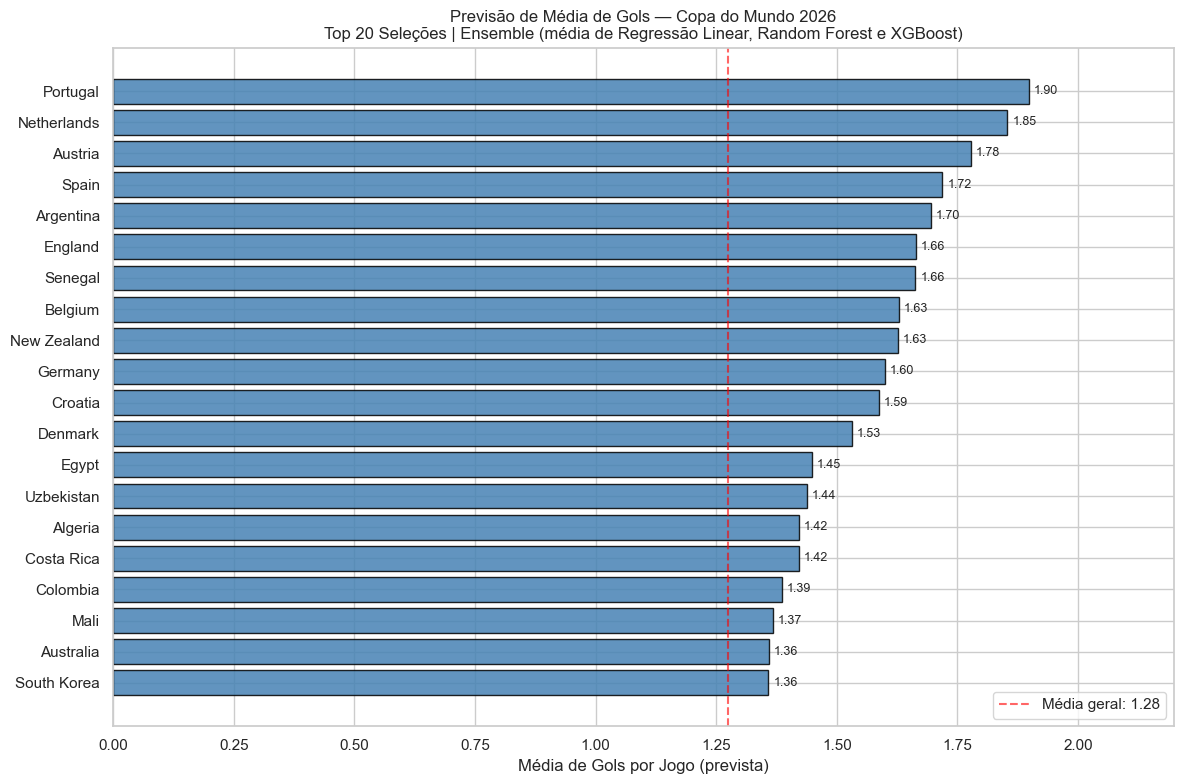

In [8]:
top20 = df_2026.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top20['selecao'][::-1], top20['pred_media'][::-1],
               color='steelblue', edgecolor='black', alpha=0.85)

for bar, val in zip(bars, top20['pred_media'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

ax.set_xlabel('Média de Gols por Jogo (prevista)')
ax.set_title(
    'Previsão de Média de Gols — Copa do Mundo 2026\n'
    'Top 20 Seleções | Ensemble (média de Regressão Linear, Random Forest e XGBoost)',
    fontsize=12
)
ax.set_xlim(0, top20['pred_media'].max() + 0.3)
ax.axvline(df_2026['pred_media'].mean(), color='red', linestyle='--',
           alpha=0.6, label=f'Média geral: {df_2026["pred_media"].mean():.2f}')
ax.legend()

plt.tight_layout()
plt.savefig('../article/figures/previsao_2026_top20.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Divergência entre Modelos

Seleções com alta divergência entre os 3 modelos representam **casos de maior incerteza** — o modelo não tem confiança na previsão.

In [9]:
print('Top 10 seleções com maior divergência entre modelos:')
print(df_2026[['selecao', 'pred_lr', 'pred_rf', 'pred_xgb', 'pred_media', 'divergencia']]
      .sort_values('divergencia', ascending=False)
      .head(10)
      .to_string(index=False))

print('\nTop 10 seleções com menor divergência (maior confiança):')
print(df_2026[['selecao', 'pred_lr', 'pred_rf', 'pred_xgb', 'pred_media', 'divergencia']]
      .sort_values('divergencia')
      .head(10)
      .to_string(index=False))

Top 10 seleções com maior divergência entre modelos:
     selecao  pred_lr  pred_rf  pred_xgb  pred_media  divergencia
      Serbia 0.848236 0.366333 -0.015203    0.399789     0.432691
        Iraq 0.922231 1.323381  1.649231    1.298281     0.364149
       Egypt 1.081331 1.513976  1.750676    1.448661     0.339419
       Japan 1.525145 1.132881  0.992606    1.216877     0.276027
Saudi Arabia 0.713591 0.546476  0.174512    0.478193     0.275950
     Jamaica 0.968076 0.838048  0.453885    0.753336     0.267358
     Denmark 1.572755 1.757357  1.264161    1.531424     0.249182
   Guatemala 0.775237 1.034095  1.271243    1.026858     0.248082
 South Korea 1.122217 1.338000  1.614826    1.358348     0.246934
  Uzbekistan 1.193140 1.458548  1.662028    1.437905     0.235125

Top 10 seleções com menor divergência (maior confiança):
      selecao  pred_lr  pred_rf  pred_xgb  pred_media  divergencia
United States 1.007242 0.996190  1.047412    1.016948     0.026955
      Morocco 1.372560 1.3179

## 10. Visualização por Confederação

C:\Users\joaog\AppData\Local\Temp\ipykernel_35160\2661936528.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_2026, x='confederacao', y='pred_media',


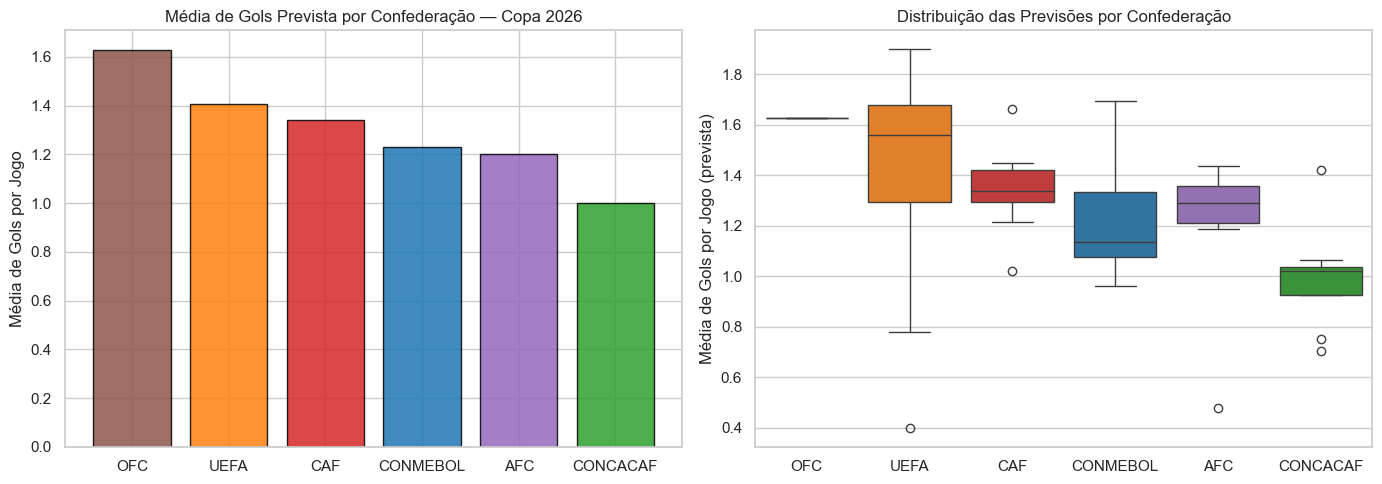


Média prevista por confederação:
confederacao
OFC         1.627
UEFA        1.407
CAF         1.341
CONMEBOL    1.232
AFC         1.202
CONCACAF    1.000


In [10]:
conf_map = {
    'Argentina': 'CONMEBOL', 'Brazil': 'CONMEBOL', 'Colombia': 'CONMEBOL',
    'Uruguay': 'CONMEBOL', 'Ecuador': 'CONMEBOL', 'Venezuela': 'CONMEBOL',
    'Germany': 'UEFA', 'Spain': 'UEFA', 'France': 'UEFA', 'England': 'UEFA',
    'Portugal': 'UEFA', 'Netherlands': 'UEFA', 'Belgium': 'UEFA', 'Italy': 'UEFA',
    'Croatia': 'UEFA', 'Switzerland': 'UEFA', 'Denmark': 'UEFA', 'Austria': 'UEFA',
    'Serbia': 'UEFA', 'Hungary': 'UEFA', 'Scotland': 'UEFA', 'Turkey': 'UEFA',
    'United States': 'CONCACAF', 'Mexico': 'CONCACAF', 'Canada': 'CONCACAF',
    'Panama': 'CONCACAF', 'Costa Rica': 'CONCACAF', 'Honduras': 'CONCACAF',
    'Jamaica': 'CONCACAF', 'Guatemala': 'CONCACAF',
    'Morocco': 'CAF', 'Senegal': 'CAF', 'Egypt': 'CAF', 'Nigeria': 'CAF',
    'South Africa': 'CAF', 'Ivory Coast': 'CAF', 'Algeria': 'CAF',
    'Cameroon': 'CAF', 'Mali': 'CAF',
    'Japan': 'AFC', 'South Korea': 'AFC', 'Iran': 'AFC', 'Australia': 'AFC',
    'Saudi Arabia': 'AFC', 'Iraq': 'AFC', 'Jordan': 'AFC', 'Uzbekistan': 'AFC',
    'New Zealand': 'OFC',
}

df_2026['confederacao'] = df_2026['selecao'].map(conf_map)

media_conf = df_2026.groupby('confederacao')['pred_media'].mean().sort_values(ascending=False)

cores_conf = {
    'CONMEBOL': '#1f77b4', 'UEFA': '#ff7f0e', 'CONCACAF': '#2ca02c',
    'CAF': '#d62728', 'AFC': '#9467bd', 'OFC': '#8c564b'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Média por confederação
cores = [cores_conf[c] for c in media_conf.index]
axes[0].bar(media_conf.index, media_conf.values, color=cores, edgecolor='black', alpha=0.85)
axes[0].set_title('Média de Gols Prevista por Confederação — Copa 2026')
axes[0].set_ylabel('Média de Gols por Jogo')
axes[0].set_xlabel('')

# Boxplot por confederação
order = media_conf.index.tolist()
sns.boxplot(data=df_2026, x='confederacao', y='pred_media',
            order=order, palette=cores_conf, ax=axes[1])
axes[1].set_title('Distribuição das Previsões por Confederação')
axes[1].set_ylabel('Média de Gols por Jogo (prevista)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('../article/figures/previsao_2026_confederacoes.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMédia prevista por confederação:')
print(media_conf.round(3).to_string())

## 11. Salvando as Previsões

In [11]:
cols_salvar = [
    'selecao', 'confederacao',
    'media_gols_marcados_ciclo', 'media_gols_marcados_ult15',
    'total_jogos_ciclo',
    'pred_lr', 'pred_rf', 'pred_xgb', 'pred_media', 'divergencia'
]

df_2026[cols_salvar].to_csv('../data/processed/previsao_2026.csv', index=False)
df_2026[cols_salvar].to_csv('../article/tables/previsao_2026.csv', index=False)

print('Previsões salvas em:')
print('  data/processed/previsao_2026.csv')
print('  article/tables/previsao_2026.csv')
print(f'\nTotal de seleções previstas: {len(df_2026)}')
print(f'\nResumo das previsões:')
print(df_2026['pred_media'].describe().round(3))

Previsões salvas em:
  data/processed/previsao_2026.csv
  article/tables/previsao_2026.csv

Total de seleções previstas: 48

Resumo das previsões:
count    48.000
mean      1.275
std       0.337
min       0.400
25%       1.056
50%       1.299
75%       1.469
max       1.899
Name: pred_media, dtype: float64


## 12. Conclusões

**Sobre as previsões:**
- Modelo final: Random Forest v1 (7 features, MAE ~0.43 na validação cruzada)
- Estimativa final: ensemble dos 3 modelos (Regressão Linear + Random Forest + XGBoost)
- Seleções com alta divergência entre modelos representam maior incerteza

**Limitações:**
- O dataset pode não conter todos os jogos do ciclo 2026 próximos à data da Copa
- A lista de classificados é uma estimativa — a classificação oficial pode diferir
- O modelo não captura lesões, mudanças de treinador ou contexto político
- Erro esperado: ~0.43–0.45 gols por jogo por seleção

**Próximo passo:** Redação do artigo técnico em `article/artigo.md`.